In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('/content/diabetes.csv')

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

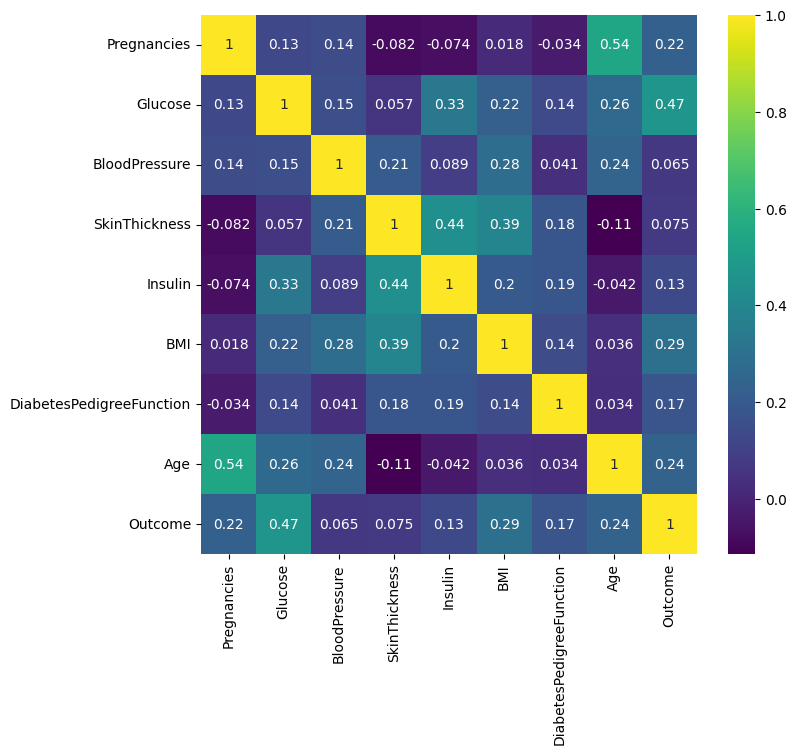

In [17]:
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(), annot=True, cmap='viridis')

<Axes: xlabel='Outcome'>

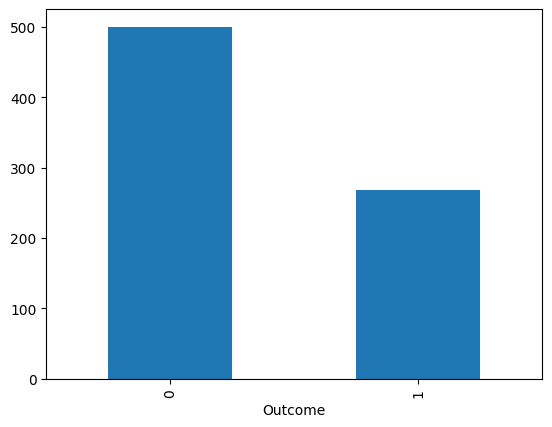

In [19]:
df['Outcome'].value_counts().plot(kind='bar')

<Axes: xlabel='BMI', ylabel='Count'>

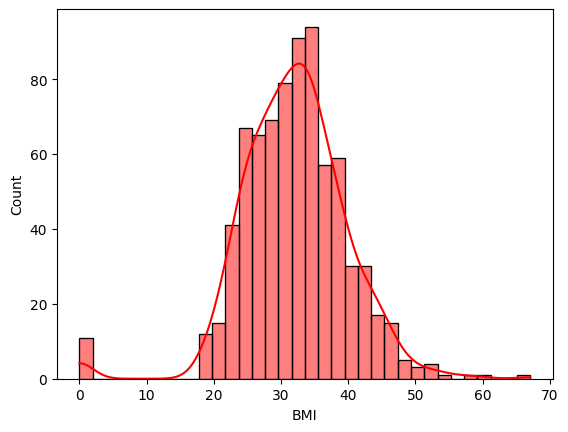

In [35]:
sns.histplot(data=df,x='BMI', kde=True, color='red')

<Axes: xlabel='BloodPressure', ylabel='Density'>

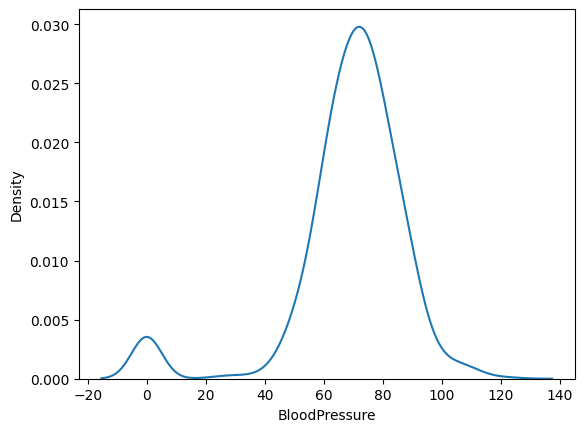

In [30]:
sns.kdeplot(data=df,x='BloodPressure')

In [36]:
X = df.drop("Outcome", axis=1)
y = df['Outcome']

In [37]:
from sklearn.model_selection import train_test_split

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.20,random_state=42)

In [52]:
from sklearn.naive_bayes import GaussianNB

In [53]:
model = GaussianNB()

In [54]:
model.fit(X_train,y_train)

GaussianNB()

In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [61]:
acc = accuracy_score(y_test,y_pred)
print(f"{acc * 100:.2f}")

73.17


In [62]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       405
           1       0.60      0.63      0.62       210

    accuracy                           0.73       615
   macro avg       0.70      0.71      0.70       615
weighted avg       0.73      0.73      0.73       615



In [63]:
metrics = confusion_matrix(y_test,y_pred)
print(metrics)

[[318  87]
 [ 78 132]]


In [64]:
from sklearn.model_selection import cross_val_score

In [69]:
validation = cross_val_score(model,X,y,cv=10,n_jobs=-1)

In [70]:
print(validation)

[0.72727273 0.75324675 0.79220779 0.71428571 0.71428571 0.79220779
 0.76623377 0.80519481 0.72368421 0.77631579]
